<a href="https://colab.research.google.com/github/deisyrestrepoo/Prediccion-Churn-Clientes-Telco-Customer-Churn/blob/feature%2Fanalisis-y-preprocesamiento/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#README

# Predicción de Churn de Clientes — Telco Customer Churn

## Integrantes del equipo
- EDGAR ANDRES GARZON MARIN
- DEISY TATIANA RESTREPO OSPINA


## Descripción del problema
Se busca predecir si un cliente de una empresa de telecomunicaciones
abandonará el servicio (churn) a partir de sus características demográficas,
los servicios contratados y su información de facturación. Es un problema
de clasificación binaria de gran relevancia para estrategias de retención.

## Fuente del conjunto de datos
Dataset "Telco Customer Churn" de Kaggle:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn
(7.043 observaciones, 21 variables)

## Objetivo del modelo
Predecir la variable `Churn` (Yes/No) para identificar clientes con alto
riesgo de abandono antes de que ocurra.

## Algoritmo utilizado


## Métrica empleada

## Principales resultados obtenidos

## Instrucciones para ejecutar el notebook
1. Abrir `notebook.ipynb` en Google Colab.
2. Configurar el secreto `KAGGLE_API_TOKEN` en Colab Secrets (icono LLAVE al lado izquierdo)
   con un token generado desde tu cuenta de Kaggle (Settings - API).
3. Ejecutar todas las celdas en orden (Runtime- Run all).
4. El modelo entrenado se guarda automáticamente en `modelo.joblib`.

# 6.1 Introducción

**Problema seleccionado:** predicción de fuga de clientes (customer churn) en
una empresa de telecomunicaciones, a partir de sus datos demográficos, los
servicios que tiene contratados y su información de cuenta y facturación.

**Objetivo del modelo:** identificar clientes con alta probabilidad de cancelar
el servicio, de manera que la empresa pueda anticipar estrategias de retención
antes de que ocurra la pérdida del cliente.

**Tipo de problema:** clasificación binaria (el cliente cancela el servicio o no).

**Variable objetivo:** Churn (Yes / No).

**Fuente de los datos:** dataset "Telco Customer Churn", disponible públicamente
en Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# 6.2 Descripción del conjunto de datos

**Número de observaciones:** 7.043 clientes.

**Número de variables:** 21 en total (20 predictoras + la variable objetivo
Churn), incluyendo el identificador customerID, que será eliminado más
adelante por no tener valor predictivo.

**Significado de la variable objetivo:** Churn indica si el cliente canceló
el servicio de la compañía (Yes) o continúa activo (No).

**Tipo de variables:**
- Numéricas: tenure (meses de antigüedad), MonthlyCharges (cargo mensual) y
  TotalCharges (cargo total acumulado).
- Categóricas: el resto de variables, entre ellas datos demográficos (gender,
  SeniorCitizen, Partner, Dependents), servicios contratados (PhoneService,
  MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
  DeviceProtection, TechSupport, StreamingTV, StreamingMovies) y datos de
  cuenta (Contract, PaperlessBilling, PaymentMethod).

**Posibles limitaciones del conjunto de datos:** es un dataset estático (una
sola instantánea en el tiempo, no permite ver la evolución del cliente antes
del churn), y la variable TotalCharges presenta un pequeño porcentaje de
valores faltantes (0.156%) correspondientes a clientes nuevos sin
facturación aún registrada.

# **Configurar el entorno**

Para descargar el dataset directamente desde Kaggle es necesario autenticarse con
una API key. En vez de escribir el token directamente en el código, lo cual sería
inseguro si se sube a GitHub, se usa Colab Secrets para
guardarlo de forma privada y cargarlo solo en tiempo de ejecución.

In [ ]:
#Cargar el token de forma segura desde Colab Secrets ---
from google.colab import userdata
import os

#Leer el secreto que guardaste en el panel de llave
kaggle_token = userdata.get('KAGGLE_API_TOKEN')

#Crear la carpeta donde la librería de Kaggle espera encontrar las credenciales
os.makedirs('/root/.kaggle', exist_ok=True)

# Guardar el token en el archivo que kaggle-cli necesita, con permisos restringidos
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(kaggle_token)
os.chmod('/root/.kaggle/access_token', 0o600)

#Exporta como variable de entorno (algunos comandos lo leen de ahí)
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("Token cargado correctamente")

Token cargado correctamente


# **Instalar la librería de Kaggle y descargar el dataset**

Se instala la librería oficial de Kaggle (`kaggle`), que permite interactuar con la
plataforma desde la línea de comandos, y se usa para descargar el dataset
"Telco Customer Churn" directamente al entorno de Colab, evitando tener que
subirlo manualmente.

In [ ]:
# Instalar cliente de Kaggle y descargar el dataset ---
!pip install -q kaggle

!kaggle datasets download -d blastchar/telco-customer-churn

!unzip -q telco-customer-churn.zip

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 85.5MB/s]



# **Cargar el CSV en un DataFrame de pandas**

Se carga el archivo CSV descargado en un DataFrame de pandas, la estructura
principal de trabajo para manipular datos tabulares en Python. Se revisan las
dimensiones y las primeras filas para confirmar que la carga fue correcta antes
de continuar con el análisis.

In [ ]:
# Cargar los datos
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)      # confirma número de filas y columnas
df.head()             # vista previa de las primeras filas

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Verificación del missing value clave**

La columna TotalCharges viene originalmente como texto (tipo object) porque
algunos valores contienen espacios en blanco en lugar de números, correspondientes
a clientes nuevos que aún no tienen facturación registrada. Al convertirla con
pd.to_numeric(errors='coerce'), esos valores no numéricos se transforman
automáticamente en NaN, lo que permite cuantificar cuántos registros están
afectados.

In [ ]:
#Confirmar el missing value que documentarás en el notebook ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing en TotalCharges: {df['TotalCharges'].isnull().sum()} de {len(df)} filas")
print(f"Porcentaje: {df['TotalCharges'].isnull().mean()*100:.3f}%")

Missing en TotalCharges: 11 de 7043 filas
Porcentaje: 0.156%


#6.3 Exploración de los datos

Antes de cualquier análisis es necesario conocer la forma general del conjunto de
datos: cuántas observaciones y variables tiene, y qué tipo de dato almacena cada
columna. Esto ayuda a detectar inconsistencias, como variables numéricas
almacenadas como texto.

In [ ]:
#Dimensiones y tipos de variables
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

Dimensiones: (7043, 21)

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


Se identifican y cuantifican los valores faltantes por variable, un paso obligatorio
antes de decidir cualquier estrategia de tratamiento (eliminación, imputación, etc.).
No basta con saber que existen faltantes; es necesario dimensionar su impacto
sobre el total de los datos.

In [ ]:
#Valores faltantes por variable
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0]
print("Valores faltantes por variable:")
print(faltantes)
print(f"\nPorcentaje sobre el total: {(faltantes / len(df) * 100).round(3)}")

Valores faltantes por variable:
TotalCharges    11
dtype: int64

Porcentaje sobre el total: TotalCharges    0.156
dtype: float64


Las estadísticas descriptivas (media, desviación estándar, mínimos, máximos,
cuartiles para las numéricas; valores únicos y más frecuentes para las categóricas)
permiten conocer el rango y la forma general de cada variable, y detectar posibles
valores atípicos o inconsistencias.

In [ ]:
# Estadísticas descriptivas
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Se analiza la distribución de la variable objetivo (Churn) para verificar si las clases
están balanceadas. Un desbalance importante entre clientes que cancelan el
servicio y los que no influye directamente en la elección de la métrica de
evaluación del modelo, ya que el accuracy puede ser engañoso en estos casos.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de churn: 26.54%


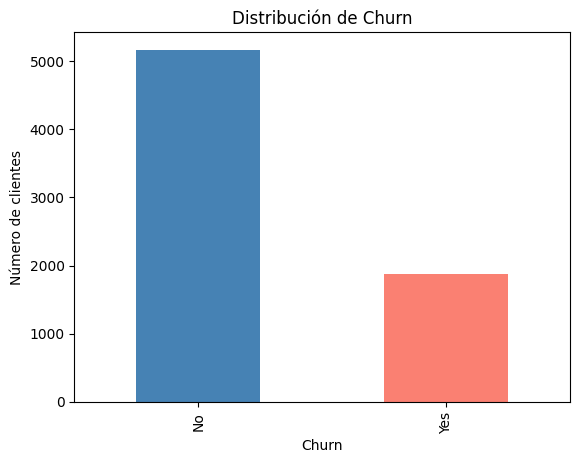

In [ ]:
#Distribución de la variable objetivo
import matplotlib.pyplot as plt

conteo_churn = df['Churn'].value_counts()
print(conteo_churn)
print(f"\nPorcentaje de churn: {(conteo_churn['Yes'] / len(df) * 100):.2f}%")

conteo_churn.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.show()

Se calcula la correlación entre las variables numéricas para identificar posibles
relaciones fuertes o redundancias entre ellas. Esto es útil para detectar
multicolinealidad, que puede afectar la interpretación de algunos modelos.

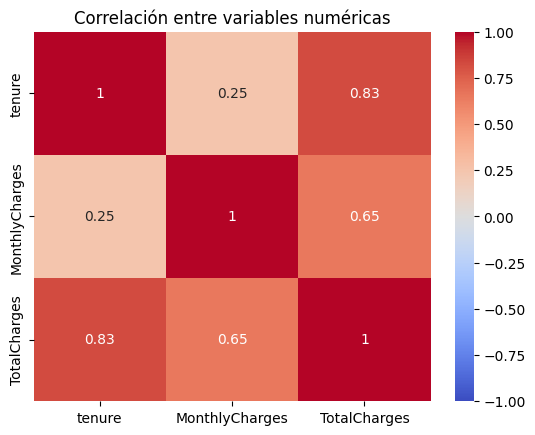

In [ ]:
#Correlación entre variables numéricas
import seaborn as sns

# tenure, MonthlyCharges y TotalCharges son las numéricas reales
numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[numericas].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas')
plt.show()

Se explora la relación entre algunas variables categóricas predictoras y la variable
objetivo, para identificar patrones que puedan orientar la construcción del modelo.
Se comparan, por ejemplo, las tasas de cancelación según el tipo de contrato y el
tipo de servicio de internet contratado.

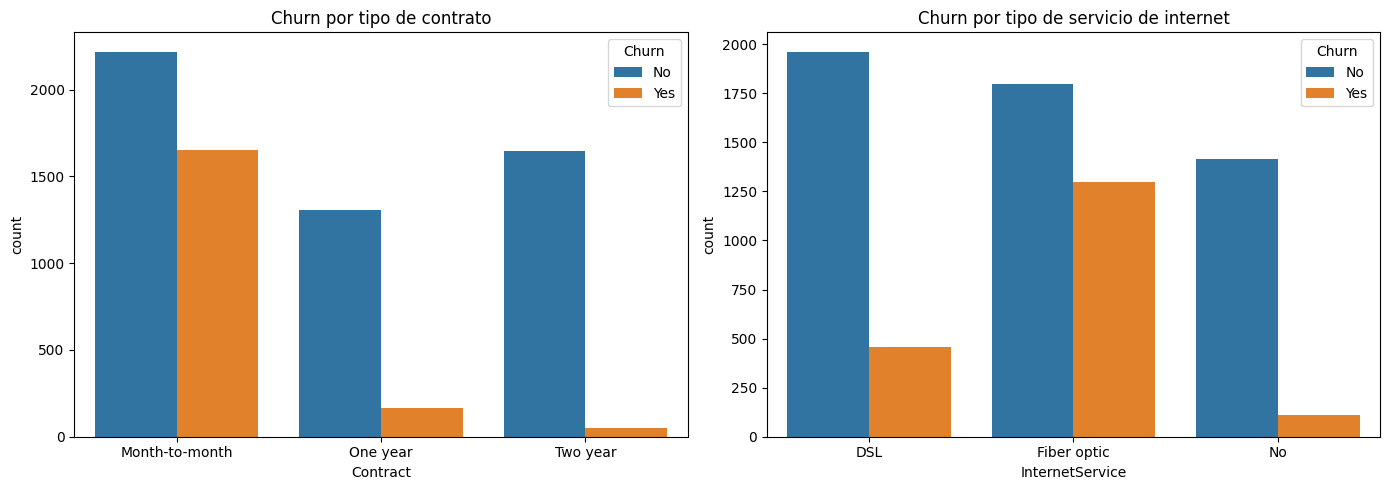

In [ ]:
# Visualización: churn por tipo de contrato
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Churn por tipo de contrato')

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1])
axes[1].set_title('Churn por tipo de servicio de internet')
plt.tight_layout()
plt.show()

Se examina la distribución individual de las variables numéricas (tenure,
MonthlyCharges, TotalCharges) para identificar su forma (simétrica o sesgada),
lo cual puede ser relevante al momento de decidir si alguna transformación o
escalamiento es necesario más adelante.

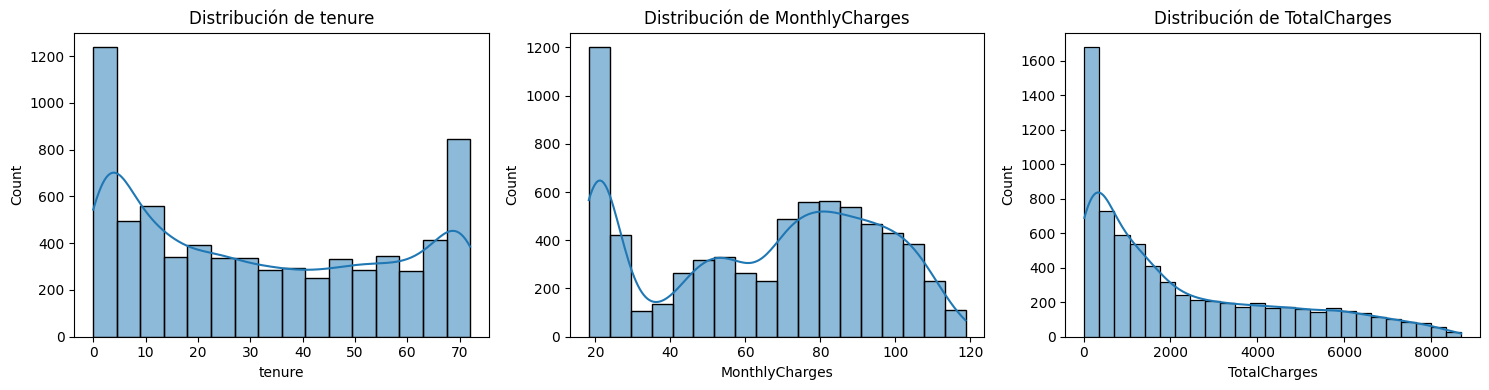

In [ ]:
# Distribución de las variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['tenure'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de tenure')

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1])
axes[1].set_title('Distribución de MonthlyCharges')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2])
axes[2].set_title('Distribución de TotalCharges')

plt.tight_layout()
plt.show()

#6.4 Preparación de los datos

Tratamiento del missing en TotalCharges:

Justificación: solo 11 filas (0.156%) tienen valor faltante, un porcentaje insignificante frente al total, por lo que eliminarlas no afecta la
representatividad del dataset ni introduce sesgo relevante.

In [ ]:
print(f"Filas antes: {len(df)}")
df = df.dropna(subset=['TotalCharges'])
print(f"Filas después: {len(df)}")

Filas antes: 7043
Filas después: 7032


Eliminación de CustomerID:

Justificación: es un identificador único sin relación con el comportamiento
del cliente, no aporta valor predictivo y podría introducir ruido o sobreajuste si se incluye.

In [ ]:
df = df.drop(columns=['customerID'])

Variable objetivo y variables binarias (Yes/No) "mapeo simple a 0/1"

In [ ]:
# Codificar el target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Codificar variables binarias Yes/No
binarias = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binarias:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# gender es binaria pero con otras etiquetas
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

Variables categóricas con más de dos valores, para no imponer un orden que no existe (por ejemplo, entre tipos de contrato)

In [ ]:
# Variables categóricas multi-clase
multiclase = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multiclase, drop_first=True)

print(df.shape)
df.head()

(7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


Verificar que no quedó ninguna columna tipo object sin codificar

In [ ]:
print(df.dtypes.value_counts())
print(df.select_dtypes(include='object').columns.tolist())

bool       21
int64       8
float64     2
Name: count, dtype: int64
[]


# 6.5 Separación de entrenamiento y prueba

Antes de continuar con transformaciones que "aprenden" de los datos (como
imputación por media/mediana o escalamiento), es necesario dividir el conjunto
en entrenamiento y prueba. Esto evita que información del conjunto de prueba
influya en decisiones tomadas durante el entrenamiento (fuga de información).

Para este tamaño de dataset se usa una división 80/20, con
stratify=y para mantener la misma proporción de clases (Yes/No) en ambos
conjuntos, dado el desbalance observado en la distribución de Churn (~26.5%).
Se fija una semilla aleatoria (random_state) para garantizar la reproducibilidad
del experimento.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")
print(f"\nProporción de churn en train: {y_train.mean():.3f}")
print(f"Proporción de churn en test: {y_test.mean():.3f}")

Entrenamiento: 5625 filas
Prueba: 1407 filas

Proporción de churn en train: 0.266
Proporción de churn en test: 0.266


# 6.6 Prevención de fuga de información

Se verifica que el proceso no presente fuga
de información (data leakage), es decir, que no se esté usando información que
en un escenario real no estaría disponible al momento de predecir.

Verificaciones realizadas:
- La variable objetivo (Churn) no se incluye entre las variables predictoras (X).
- El conjunto de prueba (X_test, y_test) no ha intervenido en ninguna
  transformación hasta este punto: el missing de TotalCharges se trató sobre
  el dataset completo porque es una eliminación de filas basada en una regla
  fija (no calculada a partir de los datos), y la codificación de variables
  categóricas (mapeo fijo Yes/No y one-hot encoding) tampoco aprende ningún
  parámetro de los datos, por lo que no genera fuga.
- No se incluyen variables que solo se conocerían después de que el cliente
  cancele el servicio (por ejemplo, no existe ninguna variable de "fecha de
  cancelación" o similar en este dataset).
- Cualquier transformación futura que sí aprenda de los datos (por ejemplo,
  escalamiento) se ajustará únicamente con X_train.

In [ ]:
# Verificación de que Churn no está en las predictoras
assert 'Churn' not in X_train.columns, "Error: la variable objetivo está en las predictoras"
print("Churn no está entre las variables predictoras: OK")

# Verificación de que no hay solapamiento entre train y test
assert len(set(X_train.index) & set(X_test.index)) == 0, "Error: hay filas repetidas entre train y test"
print("No hay solapamiento entre train y test: OK")

Churn no está entre las variables predictoras: OK
No hay solapamiento entre train y test: OK


In [ ]:
assert list(X_train.columns) == list(X_test.columns), "Error: las columnas no coinciden entre train y test"
print("Las columnas coinciden entre train y test: OK")

Las columnas coinciden entre train y test: OK


# 7. Modelo base